<a href="https://colab.research.google.com/github/eduardo-hgombrade/EDTUDOS/blob/main/BigDataPython_Lab01_EduardoHG_DadosSeguran%C3%A7a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import plotly.express as px
#Importação das bibliotecas essenciais para manipulação e visualização de dados

In [28]:
# Link atualizado e estável para a base de dados de senhas
url_senhas = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-14/passwords.csv"

# Carregando os dados com o pandas
df = pd.read_csv(url_senhas)

# Exibindo as 5 primeiras linhas para conferência
df.head()
#Carregamento do dataset de senhas em formato CSV e exibição das 5 primeiras linhas para conferência da estrutura

,rank,password,category,value,time_unit,offline_crack_sec,rank_alt,strength,font_size
0,1.0,password,password-related,6.91,years,2.170000e+00,1.0,8.0,11.0
1,2.0,123456,simple-alphanumeric,18.52,minutes,1.110000e-05,2.0,4.0,8.0
2,3.0,12345678,simple-alphanumeric,1.29,days,1.110000e-03,3.0,4.0,8.0
3,4.0,1234,simple-alphanumeric,11.11,seconds,1.110000e-07,4.0,4.0,8.0
4,5.0,qwerty,simple-alphanumeric,3.72,days,3.210000e-03,5.0,8.0,11.0


In [29]:
# 1. Verificando as informações gerais (linhas, colunas e tipos de dados)
print("--- INFO DO DATASET ---")
df.info()

# 2. Somando a quantidade exata de valores nulos (vazios) em cada coluna
print("\n--- VALORES NULOS ANTES DA LIMPEZA ---")
print(df.isnull().sum())

# 3. Limpando os dados: removendo as linhas que possuem valores vazios
df_limpo = df.dropna()

# 4. Verificando o tamanho do dataset após a limpeza
print(f"\nLinhas antes da limpeza: {df.shape[0]}")
print(f"Linhas APÓS a limpeza: {df_limpo.shape[0]}")

--- INFO DO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rank               500 non-null    float64
 1   password           500 non-null    object 
 2   category           500 non-null    object 
 3   value              500 non-null    float64
 4   time_unit          500 non-null    object 
 5   offline_crack_sec  500 non-null    float64
 6   rank_alt           500 non-null    float64
 7   strength           500 non-null    float64
 8   font_size          500 non-null    float64
dtypes: float64(6), object(3)
memory usage: 35.8+ KB

--- VALORES NULOS ANTES DA LIMPEZA ---
rank                 7
password             7
category             7
value                7
time_unit            7
offline_crack_sec    7
rank_alt             7
strength             7
font_size            7
dtype: int64

Linhas antes da limpeza: 507
L

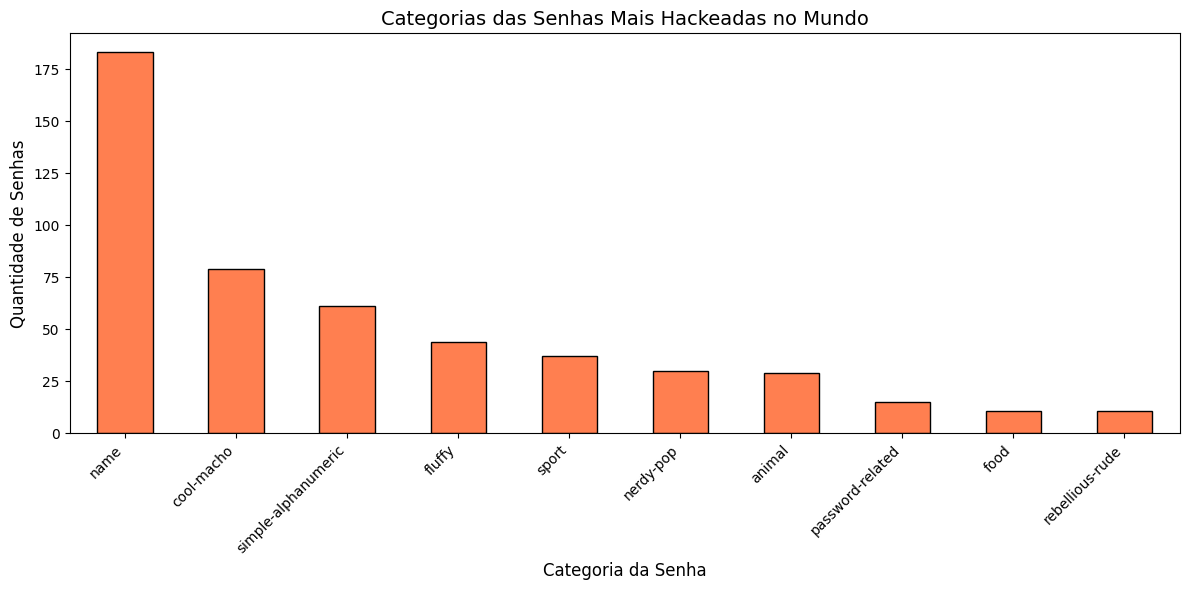

In [30]:
# 1. Agrupando as senhas por categoria e contando a quantidade
contagem_categorias = df_limpo['category'].value_counts()

# 2. Criando o Gráfico de Barras
plt.figure(figsize=(12, 6))
contagem_categorias.plot(kind='bar', color='coral', edgecolor='black')

# 3. Adicionando títulos e rótulos
plt.title('Categorias das Senhas Mais Hackeadas no Mundo', fontsize=14)
plt.xlabel('Categoria da Senha', fontsize=12)
plt.ylabel('Quantidade de Senhas', fontsize=12)

# 4. Ajustando a rotação das palavras no eixo X para facilitar a leitura
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 5. Exibindo o gráfico
plt.show()

##Agrupamento das senhas por categoria e geração de um gráfico de barras para visualizar os padrões mais vulneráveis escolhidos pelos usuários.

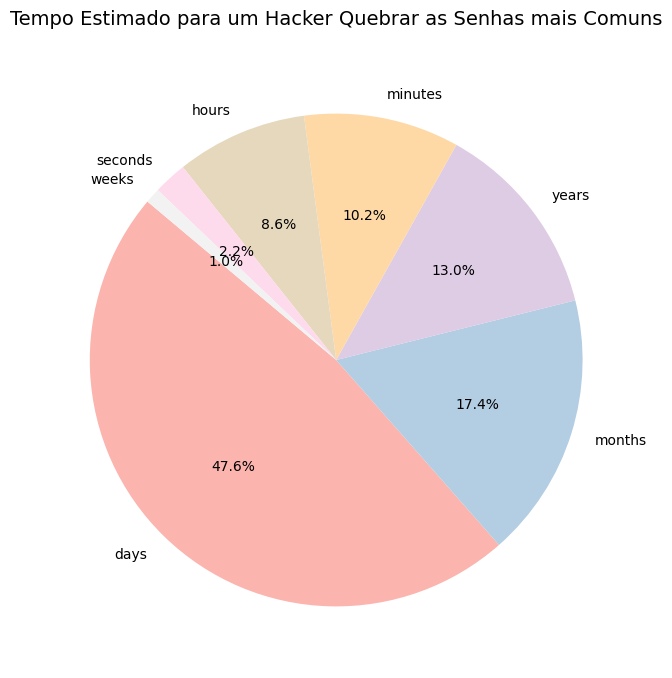

In [31]:
# 1. Agrupando as senhas pela unidade de tempo que o hacker levaria para quebrar
contagem_tempo = df_limpo['time_unit'].value_counts()

# 2. Criando o Gráfico de Pizza
plt.figure(figsize=(8, 8))
# Usando autopct para mostrar a porcentagem e colormap para cores diferentes
contagem_tempo.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='Pastel1')

# 3. Adicionando título e limpando o eixo Y
plt.title('Tempo Estimado para um Hacker Quebrar as Senhas mais Comuns', fontsize=14, pad=20)
plt.ylabel('')

# 4. Exibindo o gráfico
plt.show()

##Criação de um gráfico de pizza para demonstrar a proporção de senhas vulneráveis que podem ser quebradas em segundos ou minutos.

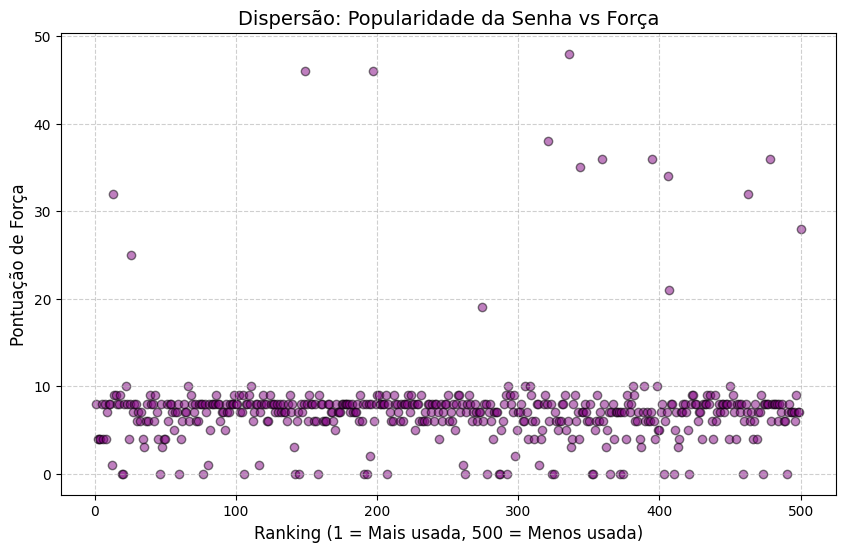

In [34]:
# 1. Criando o Gráfico de Dispersão (Scatter Plot)
plt.figure(figsize=(10, 6))

# Cruzando o Ranking (popularidade) com a Força da senha
# O 'alpha=0.5' deixa as bolinhas transparentes para vermos onde elas se sobrepõem
plt.scatter(df_limpo['rank'], df_limpo['strength'], color='purple', alpha=0.5, edgecolor='black')

# 2. Adicionando títulos e rótulos
plt.title('Dispersão: Popularidade da Senha vs Força', fontsize=14)
plt.xlabel('Ranking (1 = Mais usada, 500 = Menos usada)', fontsize=12)
plt.ylabel('Pontuação de Força', fontsize=12)

# 3. Adicionando uma grade para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Exibindo o gráfico
plt.show()

##Gráfico de dispersão cruzando o ranking de uso das senhas com suas pontuações de força, evidenciando uma densa concentração na zona de alta vulnerabilidade.

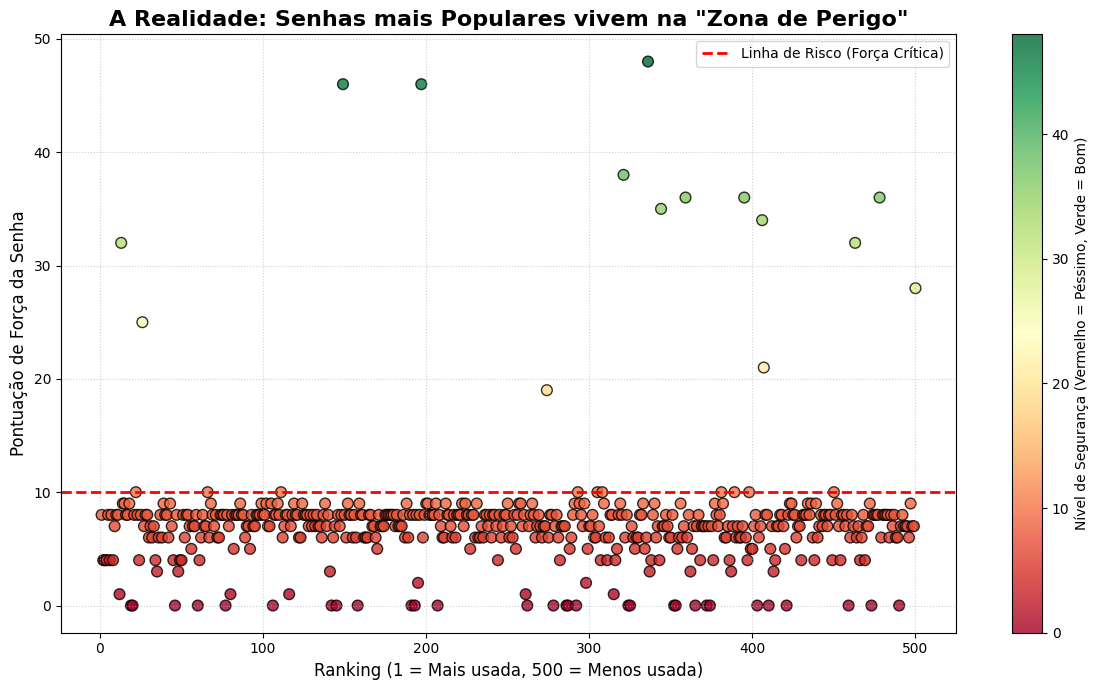

In [35]:
# 1. Criando o Gráfico de Dispersão Melhorado
plt.figure(figsize=(12, 7))

# Usando 'c' para vincular a cor à força da senha e 'cmap' para o gradiente (Red-Yellow-Green)
# Aumentei o tamanho das bolinhas ('s=60') para destacar mais
scatter = plt.scatter(df_limpo['rank'], df_limpo['strength'],
                      c=df_limpo['strength'], cmap='RdYlGn',
                      alpha=0.8, edgecolor='black', s=60)

# 2. Adicionando a Linha de Alerta (Zona Crítica)
plt.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Linha de Risco (Força Crítica)')

# 3. Textos mais diretos e impactantes
plt.title('A Realidade: Senhas mais Populares vivem na "Zona de Perigo"', fontsize=16, fontweight='bold')
plt.xlabel('Ranking (1 = Mais usada, 500 = Menos usada)', fontsize=12)
plt.ylabel('Pontuação de Força da Senha', fontsize=12)

# 4. Adicionando uma barra lateral para explicar as cores
cbar = plt.colorbar(scatter)
cbar.set_label('Nível de Segurança (Vermelho = Péssimo, Verde = Bom)')

# 5. Acabamentos finais
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Exibindo o gráfico
plt.show()

##Gráfico de dispersão aprimorado com mapa de calor (RdYlGn) e linha de limite crítico, evidenciando visualmente que a esmagadora maioria das senhas mais populares falha nos testes básicos de segurança.